In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("../data/churn-bigml.csv")   
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [ ]:
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include=['object', 'string']):
    df[col].fillna(df[col].mode()[0], inplace=True)
df[df.select_dtypes(include=['int64','float64']).columns] = \
df.select_dtypes(include=['int64','float64']).fillna(df.mean(numeric_only=True))
for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
numeric_df = df.select_dtypes(include=['int64','float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((numeric_df < (Q1 - 1.5 * IQR))  
        | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]


for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]



C:\Users\DELL\AppData\Local\Temp\ipykernel_12240\1731792059.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
Before: (406, 20)
After removing outliers: (406, 20)


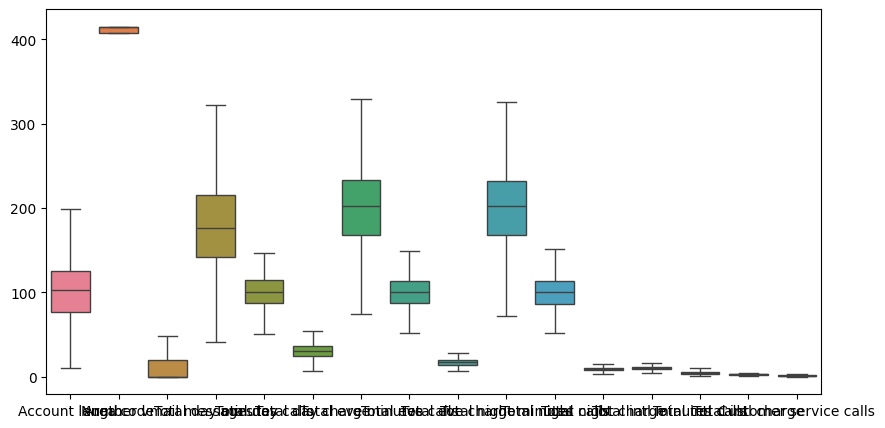

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
                     (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    print("Before:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

plt.figure(figsize=(10,5))
sns.boxplot(data=numeric_df)
plt.show()






In [26]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3,SC,0.211949,0.705801,No,No,-0.607178,-1.295385,0.074016,-1.295244,-1.352096,0.096720,-1.352201,-0.245479,0.267151,-0.246379,-1.081162,0.757800,-1.080528,0.697626,False
5,AK,-1.749108,-1.416830,No,Yes,1.595152,-0.612295,1.347350,-0.612480,-0.820965,-1.116627,-0.821578,-1.504834,0.470171,-1.503947,1.705054,0.757800,1.712253,-1.362273,False
6,MI,-0.990833,0.705801,No,No,-0.607178,0.624498,0.939883,0.624329,-0.818858,1.199763,-0.819099,-1.392056,0.926965,-1.392576,1.172395,0.287361,1.165840,1.727575,False
8,VA,-2.428941,-1.416830,No,No,-0.607178,0.145003,0.532417,0.145275,-0.237143,-1.888757,-0.236406,1.700987,-2.169086,1.702619,0.434867,0.757800,0.437288,0.697626,False
11,HI,-0.467884,0.705801,No,No,-0.607178,1.090674,0.379617,1.091071,-0.932672,-0.344497,-0.933158,-0.274718,-0.037379,-0.274222,0.680709,-0.653515,0.680139,-1.362273,False


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])

df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3,40,0.534392,1.0,0,0,0.000,0.246804,0.541667,0.246867,0.245690,0.515464,0.245735,0.462145,0.535354,0.461876,0.293651,0.555556,0.294118,0.666667,False
5,0,0.137566,0.0,0,1,0.625,0.374290,0.802083,0.374269,0.344436,0.288660,0.344398,0.224369,0.575758,0.224365,0.833333,0.555556,0.835294,0.000000,False
6,22,0.291005,1.0,0,0,0.000,0.605114,0.718750,0.605054,0.344828,0.721649,0.344859,0.245662,0.666667,0.245399,0.730159,0.444444,0.729412,1.000000,False
8,45,0.000000,0.0,0,0,0.000,0.515625,0.635417,0.515664,0.452978,0.144330,0.453204,0.829653,0.050505,0.829974,0.587302,0.555556,0.588235,0.666667,False
11,11,0.396825,1.0,0,0,0.000,0.692116,0.604167,0.692147,0.323668,0.432990,0.323651,0.456625,0.474747,0.456617,0.634921,0.222222,0.635294,0.000000,False


In [ ]:
rfm = df.groupby(df.index).agg({
    'Account length': 'mean',       
    'Total day calls': 'sum',         
    'Total day charge': 'sum'       
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

df['TotalCalls'] = df['Total day calls'] + df['Total eve calls'] + df['Total night calls'] + df['Total intl calls']
df['TotalMinutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['SupportCalls'] = df['Customer service calls']
behavior = df[['TotalCalls','TotalMinutes','SupportCalls']]
behavior.head()
df['Minutes_per_Call'] = df['TotalMinutes'] / df['TotalCalls']
df['Charge_per_Minute'] = df['Total day charge'] / df['Total day minutes']
df['SupportCall_Ratio'] = df['Customer service calls'] / df['TotalCalls']
df[['Minutes_per_Call','Charge_per_Minute','SupportCall_Ratio']].head()




,Minutes_per_Call,Charge_per_Minute,SupportCall_Ratio
3,0.581130,1.000256,0.310360
5,0.799452,0.999945,0.000000
6,0.754754,0.999902,0.391925
8,1.721421,1.000076,0.481067
11,1.215211,1.000044,0.000000


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])


In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])
